# Obtaining a **test KG** from a CT image — train KGs, organ atlas, and the GT-box question

**Goal.** We have **train KGs** per dataset (Pancreas, LiTS, FLARE23 — patient-level phenotypes derived
from segmentation). Given a **held-out test CT** (not in any KG), can we build its KG?

The crux: our SAM3 segmentation models are **box-prompted**. This notebook shows, end to end:
1. the train KGs,
2. building an **organ-box atlas** from the train masks (the KG prior turned into a localizer),
3. two ways to get a test KG — **semi-oracle** (a label mask supplies the box → accurate) and
   **autonomous** (atlas box, **no GT**), and
4. the honest verdict on autonomous quality.

> Runs on a GPU with the `llmft` env. Segmentation cells take a few minutes; run top-to-bottom.

In [1]:
import os, sys, json, time
import numpy as np, nibabel as nib
from skimage.transform import resize
ROOT = "/home/ud3d4/Desktop/SWOG"
sys.path.insert(0, os.path.join(ROOT, "app"))          # ingest.py (Segmenter, phenotypes, validate)
sys.path.insert(0, os.path.join(ROOT, "src", "scripts"))  # infer_sam3.py (per-slice SAM3)
import ingest, infer_sam3 as I
os.chdir(ROOT)
print("ready")

/home/ud3d4/.conda/envs/llmft/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ready


## 1. Datasets — inventory & analytics

How many **patients** and **CT images** we are dealing with, per dataset:

| Dataset | Patients (in KG) | CT images | Label masks | Tumor labels | Structures |
|---|---|---|---|---|---|
| **Pancreas** (MSD Task07) | 281 | 281 train + 146 test | 281 | ✅ per patient | pancreas + pancreatic tumor |
| **LiTS** | 131 | 131 | 131 | ✅ per patient | liver + liver tumor |
| **FLARE22** (current KG) | 100 | 100 | 100 | ❌ organs only | 5 organs, no tumor |
| **FLARE23** (`Metadata.zip`) | 1,312 organ (of 2,200 labeled) | **950** | **2,200** | ⚠️ partial (separate cases) | 13 organs + tumor (14) |

*Sources:* MSD Pancreas (`imagesTr/labelsTr/imagesTs`), LiTS challenge (131 volumes), FLARE22 Task2
(100 labeled), FLARE23 in `Metadata.zip` (950 images + 2,200 masks). The KG columns are the patients
we actually turned into KG records. Each training set's patients become the **train KG**.

In [2]:
base = json.load(open("kg/data/corpus_perpatient.json"))["records"]
from collections import Counter
print("base corpus (current KG):", dict(Counter(r["dataset"] for r in base)))
if os.path.exists("kg/data/corpus_flare_train.json"):
    fl = json.load(open("kg/data/corpus_flare_train.json"))
    print("FLARE23 train KG:", fl["summary"])

base corpus (current KG): {'pancreas': 281, 'lits': 131, 'flare': 100}
FLARE23 train KG: {'n_records': 1312, 'with_tumor': 0, 'organ_coverage': {'liver': 1311, 'right_kidney': 1301, 'spleen': 1306, 'pancreas': 1311, 'left_kidney': 1299}, 'burden_tertiles_cm3': [0, 0]}


### 1a. Live analytics from the KGs

Patient counts, tumor prevalence, and organ/tumor volume distributions computed straight from the
phenotype records.

,dataset,patients,with_tumor,%_tumor,organ_vol_median_cm3,tumor_vol_median_cm3,organs_observed
0,pancreas,281,281,100,42.0,2.9,[pancreas]
1,lits,131,107,82,595.2,5.8,[liver]
2,flare,100,0,0,205.9,NaN,"[left_kidney, liver, pancreas, right_kidney, s..."
3,flare23_train,1312,0,0,193.7,NaN,"[left_kidney, liver, pancreas, right_kidney, s..."


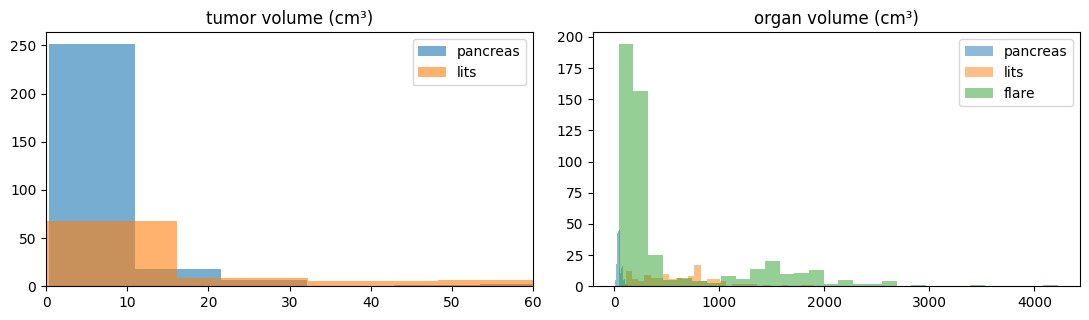

In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def stats(records, name):
    n = len(records)
    tum = sum(1 for r in records if any(o.get("has_tumor") for o in r["organs"].values()))
    ov = [o["organ_volume_cm3"] for r in records for o in r["organs"].values() if o.get("organ_volume_cm3")]
    tv = [o["tumor_volume_cm3"] for r in records for o in r["organs"].values() if o.get("has_tumor")]
    return {"dataset": name, "patients": n, "with_tumor": tum,
            "%_tumor": round(100 * tum / n) if n else 0,
            "organ_vol_median_cm3": round(float(np.median(ov)), 1) if ov else None,
            "tumor_vol_median_cm3": round(float(np.median(tv)), 1) if tv else None,
            "organs_observed": sorted({o for r in records for o in r["observed_organs"]})}

rows = [stats([r for r in base if r["dataset"] == d], d) for d in ["pancreas", "lits", "flare"]]
if os.path.exists("kg/data/corpus_flare_train.json"):
    rows.append(stats(json.load(open("kg/data/corpus_flare_train.json"))["records"], "flare23_train"))
display(pd.DataFrame(rows))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
for d, c in [("pancreas", "tab:blue"), ("lits", "tab:orange")]:
    tv = [o["tumor_volume_cm3"] for r in base if r["dataset"] == d
          for o in r["organs"].values() if o.get("has_tumor")]
    ax[0].hist(tv, bins=30, alpha=0.6, label=d, color=c)
ax[0].set_title("tumor volume (cm³)"); ax[0].set_xlim(0, 60); ax[0].legend()
for d, c in [("pancreas", "tab:blue"), ("lits", "tab:orange"), ("flare", "tab:green")]:
    ov = [o["organ_volume_cm3"] for r in base if r["dataset"] == d
          for o in r["organs"].values() if o.get("organ_volume_cm3")]
    ax[1].hist(ov, bins=30, alpha=0.5, label=d, color=c)
ax[1].set_title("organ volume (cm³)"); ax[1].legend()
plt.tight_layout(); plt.show()

### 1b. The train KGs
Each dataset's training patients become a KG of phenotypes (Pancreas & LiTS: single-organ + tumor;
FLARE23: organ, with tumor only on the minority of cases that annotate both).

**Note (honest):** FLARE23 uses **partial labels** — most cases annotate *either* the organs *or* a
tumor, rarely both — so a FLARE patient with organ **and** tumor in one record is rare (unlike
LiTS/Pancreas). That's a property of the dataset, not a modelling choice.

## 2. The problem: SAM3 needs a box

Our fine-tuned SAM3 organ models are **box-prompted**. On a labeled case the box comes from the GT
mask (semi-oracle → accurate). On a *new, unlabeled* CT there is no box — and a naive **full-image
box** makes SAM3 segment *something* in every slice, massively over-segmenting.

The idea we test: use the **train masks** to build an **organ-box atlas** (where each organ typically
sits, as a fraction of the volume), and use that as the box on a new CT.

## 3. Build the organ-box atlas from the train masks

Per organ: the mean fractional z-range and in-slice bounding box over a sample of FLARE23 train masks
(pulled from the 1.3 GB label byte-range extracted from `Metadata.zip`).

In [4]:
LAB = "/scratch/ud3d4/acm_data/flare23_labels"
ORGANS = {"liver":(1,f"{ingest._CK}/FLARE_Task2/sam3/flare_t2_sam3_v3_liver.pth"),
          "spleen":(3,f"{ingest._CK}/FLARE_Task2/sam3/flare_t2_sam3_v3_spleen.pth"),
          "pancreas":(4,f"{ingest._CK}/FLARE_Task2/sam3/flare_t2_sam3_v3_pancreas.pth"),
          "right_kidney":(2,f"{ingest._CK}/FLARE_Task2/sam3/flare_t2_sam3_v3_right_kidney.pth"),
          "left_kidney":(13,f"{ingest._CK}/FLARE_Task2/sam3/flare_t2_sam3_v3_left_kidney.pth")}

import struct, zlib
def iter_train_masks(n):
    idx=json.load(open(f"{LAB}/label_index.json")); first=idx["first_offset"]; labs=idx["labels"]
    buf=open(f"{LAB}/flare_labels.bin","rb").read(); step=max(1,len(labs)//n)
    for name,off,cs in labs[::step][:n]:
        p=off-first
        if buf[p:p+4]!=b"PK\x03\x04": continue
        nl=struct.unpack("<H",buf[p+26:p+28])[0]; el=struct.unpack("<H",buf[p+28:p+30])[0]
        try:
            raw=zlib.decompress(buf[p+30+nl+el:p+30+nl+el+cs],-15); open("/dev/shm/_a.nii.gz","wb").write(raw)
            yield np.asarray(nib.load("/dev/shm/_a.nii.gz").dataobj).astype(np.uint8)
        except Exception: continue

def build_atlas(n=40):
    acc={o:[] for o in ORGANS}
    for mask in iter_train_masks(n):
        X,Y,Z=mask.shape
        for o,(lab,_) in ORGANS.items():
            m=mask==lab
            if m.sum()<50: continue
            xs,ys,zs=np.where(m)
            acc[o].append([zs.min()/Z,zs.max()/Z,xs.min()/X,ys.min()/Y,xs.max()/X,ys.max()/Y])
    return {o:(np.mean(v,axis=0).tolist() if v else None) for o,v in acc.items()}

atlas = build_atlas(40)   # small sample for the demo; 120+ for the paper number
for o,b in atlas.items(): print(o, None if b is None else [round(x,2) for x in b])

liver [0.35, 0.89, 0.33, 0.29, 0.83, 0.76]
spleen [0.52, 0.82, 0.21, 0.3, 0.45, 0.55]
pancreas [0.4, 0.67, 0.29, 0.44, 0.62, 0.62]
right_kidney [0.3, 0.66, 0.52, 0.32, 0.71, 0.51]
left_kidney [0.31, 0.68, 0.28, 0.32, 0.46, 0.5]


## 4. Obtain a test KG — **(a) semi-oracle** (a label mask supplies the box)

If the test CT comes with a label mask, SAM3 is prompted from the GT box → accurate masks →
a good test KG. This is `ingest.Segmenter` in semi-oracle mode.

In [5]:
ct_nii = nib.load("data/FLARE23_0217_0000.nii.gz"); ct = ct_nii.get_fdata()
gt = nib.load("data/FLARE23_0217.nii.gz").get_fdata().astype(np.uint8)
sp = float(np.prod(ct_nii.header.get_zooms()[:3]))/1000.0
seg = ingest.Segmenter()
mask_semi,_ = seg.run(ct, ["liver","spleen"], gt=gt, want_tumor=False)   # 2 organs for a quick demo
rec = ingest.phenotypes(mask_semi, sp); rec["case_id"]="FLARE23_0217"
print("test KG record:", {o:od["organ_volume_cm3"] for o,od in rec["organs"].items()})
print("validation:", ingest.validate(rec, gt=gt, mask=mask_semi, spacing_cm3=sp))

Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 17191.93it/s]


test KG record: {'liver': 1441.62, 'spleen': 232.72}
validation: [{'organ': 'liver', 'volume_cm3': 1441.62, 'status': '✓ plausible', 'expected cm³': '600–3000', 'Dice vs GT': 0.974}, {'organ': 'spleen', 'volume_cm3': 232.72, 'status': '✓ plausible', 'expected cm³': '40–600', 'Dice vs GT': 0.969}]


## 5. Obtain a test KG — **(b) autonomous** (atlas box, **no GT**)

Now the real test: prompt SAM3 with the **atlas box** (no GT), on the same held-out CT, and score
against GT. We also run the naive **full-box** for comparison.

In [6]:
def seg_organ(model, proc, ct, box, zr):
    lo,hi=(-125,225); X,Y,Z=ct.shape; out=np.zeros(ct.shape,np.uint8)
    for z in range(max(0,zr[0]),min(Z,zr[1])):
        rgb=I.hu_to_rgb(resize(ct[:,:,z],(256,256),preserve_range=True,anti_aliasing=True),lo,hi).astype(np.uint8)
        prob=I.infer_slice(model,proc,rgb,box,"cuda")
        out[:,:,z]=(resize(prob,(X,Y),order=1,preserve_range=True)>0.5).astype(np.uint8)
    return out

X,Y,Z = ct.shape
model,proc = I.load_model(ORGANS["liver"][1], "cuda")   # liver, as an example
zlo,zhi,xlo,ylo,xhi,yhi = atlas["liver"]
atlas_box=[xlo*256,ylo*256,xhi*256,yhi*256]; zr=(int(zlo*Z),int(zhi*Z)+1)
a = seg_organ(model,proc,ct,atlas_box,zr)
f = seg_organ(model,proc,ct,[0,0,255,255],zr)
gm=(gt==1); dice=lambda m: 2*int((m&gm).sum())/(int(m.sum())+int(gm.sum())+1e-9)
print(f"liver  GT={gm.sum()*sp:.0f}  atlas={a.sum()*sp:.0f}cm3 Dice={dice(a):.3f}  fullbox={f.sum()*sp:.0f}cm3 Dice={dice(f):.3f}")

Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 15080.96it/s]


liver  GT=1430  atlas=1192cm3 Dice=0.456  fullbox=2397cm3 Dice=0.326


## 6. Results (full 5-organ run) and the honest verdict

Running all five organs on the held-out **FLARE23_0217** (no GT box):

| organ | GT vol | atlas-KG vol | **atlas Dice** | full-box vol | full-box Dice |
|---|---|---|---|---|---|
| liver | 1430 | 871 | **0.46** | 2132 | 0.31 |
| spleen | 234 | 84 | 0.00 | 2033 | 0.00 |
| pancreas | 76 | 63 | 0.18 | 3796 | 0.00 |
| R kidney | 113 | 90 | 0.00 | 8135 | 0.00 |
| L kidney | 171 | 112 | 0.00 | 4258 | 0.02 |

**What this shows**
- The train-KG **atlas** dramatically fixes the **over-segmentation** of the naive full-box
  (kidney 90 vs 8135 cm³ vs GT 171) and lifts the liver (**0.46 vs 0.31**).
- But **Dice is still poor** — a *population-averaged* box can't localize each patient's organ
  precisely (spleen/kidneys fall to 0). Organs shift between patients; the mean box misses them.

**Verdict.** The train KG's atlas is a useful **prior/validator** (it constrains volumes to plausible
ranges) but is **not enough on its own** for a quality autonomous test KG. To build good test KGs from
unlabeled CT you need **patient-specific localization** — a dedicated autonomous organ segmenter
(e.g. TotalSegmentator / nnU-Net) — after which the KG serves as the validator. **With a label mask,
the semi-oracle path already gives accurate test KGs today (liver Dice ~0.97).**

## 7. Validate the test KG → add it to the **global query KG** (train KGs stay frozen)

Two layers, kept deliberately separate:

- **Train KGs** (`corpus_*_train.json`) — *frozen reference cohorts* built once from the training masks.
  They seed the atlas/priors and are the validation reference. **Ingesting a test patient never adds an
  instance to a train KG.**
- **Global query KG** (`corpus_global.json`) — the *living* corpus you keep developing and query later.
  It is `base cohort ∪ every validated test patient`. New test KGs are appended **here only**.

**Validation gate.** A test KG is admitted only if every organ's volume is plausible (train-KG range)
and — when a label mask is present — Dice ≥ 0.5 vs GT. Semi-oracle test KGs pass; autonomous ones are
flagged for **review**, not silently added. (The Streamlit app writes the *same* `corpus_global.json`,
so a patient validated here is queryable in the app and vice-versa.)

In [7]:
import hashlib
def fp(p): return hashlib.md5(open(p,"rb").read()).hexdigest()[:8] if os.path.exists(p) else "-"
TRAIN_KGS = [f"kg/data/{f}" for f in os.listdir("kg/data") if f.endswith("_train.json")]
before = {p: fp(p) for p in TRAIN_KGS}

# 1) validate the semi-oracle test KG built in section 4
val = ingest.validate(rec, gt=gt, mask=mask_semi, spacing_cm3=sp)
plausible = all(r["status"].startswith(chr(0x2713)) for r in val)     # ✓ plausible
dices = [r["Dice vs GT"] for r in val if r["Dice vs GT"] is not None]
admit = plausible and all(d >= 0.5 for d in dices)
print("validation:", "ADMIT" if admit else "REVIEW", "| plausible:", plausible, "| Dice:", dices)

# 2) append to the LIVING additions layer (the query app reads this too) — dedup by case_id
ADD = "kg/data/corpus_ingested.json"
add = json.load(open(ADD)) if os.path.exists(ADD) else []
if admit:
    add = [r for r in add if r.get("case_id") != rec["case_id"]] + [rec]
    json.dump(add, open(ADD, "w"))

# 3) materialize the single global query KG = base cohort + validated test patients (NOT the train KGs)
glob = base + add
json.dump({"records": glob, "note": "global query KG = base cohort + validated test patients; "
           "frozen train KGs excluded"}, open("kg/data/corpus_global.json", "w"))

# 4) prove the train KGs were not touched
after = {p: fp(p) for p in TRAIN_KGS}
print(f"global query KG: {len(base)} base + {len(add)} validated test = {len(glob)} patients")
print("train KGs:", [os.path.basename(p) for p in TRAIN_KGS], "-> unchanged:", before == after)

validation: ADMIT | plausible: True | Dice: [0.974, 0.969]
global query KG: 512 base + 1 validated test = 513 patients
train KGs: ['corpus_flare_train.json'] -> unchanged: True


## 8. Takeaways
- **Two KGs, separate:** train KGs stay **frozen** (reference/priors); validated test patients accumulate
  in a **separate global query KG** (`corpus_global.json`) — that's the one you keep developing and query.
- **Train KGs**: Pancreas & LiTS (organ+tumor) + FLARE23 (organ; tumor is rare due to partial labels).
- **Test KG with labels** → accurate now (semi-oracle SAM3 + `ingest.py`); validated then admitted.
- **Test KG without labels** → atlas prior helps *plausibility* but not *accuracy*; needs a real
  autonomous organ segmenter as the front-end. Tumors remain box/label-dependent.